Gray-box attack - SimBA([here](https://arxiv.org/abs/1905.07121))

Cannot access the model weights, but we do get classifier confidence scores

In [ ]:
import torch
from PIL import Image
from IPython import display

import pandas as pd
import torchvision
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:

model = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', weights='MobileNet_V2_Weights.DEFAULT', verbose=False)

# Put model in evaluation mode
model.eval()

# put the model on a GPU if available, otherwise CPU
model.to(device);

# Define the transforms for preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),  # Resize the image to 256x256
    transforms.CenterCrop(224),  # Crop the image to 224x224 about the center
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Normalize the image with the ImageNet dataset mean values
        std=[0.229, 0.224, 0.225]  # Normalize the image with the ImageNet dataset standard deviation values
    )
]);

unnormalize = transforms.Normalize(
   mean= [-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
   std= [1/s for s in [0.229, 0.224, 0.225]]
)

with open("/content/labels.txt", 'r') as f:
    labels = [label.strip() for label in f.readlines()]


img = Image.open("/content/Riley.jpg")
img_tensor = preprocess(img).unsqueeze(0)
img_tensor = img_tensor.to(device)

with torch.no_grad():
    output = model(img_tensor)

print(f"Image tensor on device:\n---------------\n{img_tensor.device}\n")
print(f"Inputs information:\n---------------\nshape:{img_tensor.shape}\nclass: {type(img_tensor)}\n")
print(f"Shape of outputs:\n---------------\n{output.shape}\n")
print(f"Pred Index:\n---------------\n{output[0].argmax()}\n")
print(f"Pred Label:\n---------------\n{labels[output[0].argmax()]}\n")

unnormed_img_tensor= unnormalize(img_tensor)

img_pil = transforms.functional.to_pil_image(unnormed_img_tensor[0])
img_pil.show()

Image tensor on device:
---------------
cuda:0

Inputs information:
---------------
shape:torch.Size([1, 3, 224, 224])
class: <class 'torch.Tensor'>

Shape of outputs:
---------------
torch.Size([1, 1000])

Pred Index:
---------------
230

Pred Label:
---------------
Shetland sheepdog



In [ ]:
# create new img_tensor
img_tensor = preprocess(img).unsqueeze(0).to(device)

In [ ]:
n_masks = 1000
eta = 0.005

mask_collection = torch.randn((n_masks, *img_tensor.shape)).to(device)*eta

current_mask = torch.zeros_like(img_tensor).to(device)

In [ ]:
# compute our starting index

starting_index = model(img_tensor).argmax(1)
print(f"Starting index is:\n---------------\n{starting_index}\n")

starting_class_score = model(img_tensor + current_mask)[0, starting_index.item()].item()
print(f"Starting class score is:\n---------------\n{starting_class_score}\n")

Starting index is:
---------------
tensor([230], device='cuda:0')

Starting class score is:
---------------
5.427470684051514



In [ ]:
# Zero our current mask
current_mask = torch.zeros_like(img_tensor).to(device)

# Get our starting label index
starting_label = model(img_tensor).argmax(1)
current_label = starting_label

# Get our starting confidence score
best_score = model(img_tensor + current_mask)[0, starting_index.item()].item()

# Run until we reclassify successfully ...
while current_label == starting_label:


    # Select a random mask from the collection we created
    mask_candidate_idx = np.random.choice(len(mask_collection))
    mask_candidate = mask_collection[mask_candidate_idx]

    # Don't store gradient information while doing inference
    with torch.no_grad():
        # get the scores for the image if we updated the current mask to
        # use the candidate we just randomly picked
        output = model(img_tensor + current_mask + mask_candidate)

    # select the most probable label from the output of the model with the candidate mask in play
    current_label = output.argmax(1).item()
    # our score will be the score of our original label: we want this to go _down_ (i.e. the current
    # label to become less likely)
    new_score = output[0, starting_label.item()].item()

    # If the score for the current class -- the one we're trying to get away from -- did not decrease, then
    # skip back to the beginning and pick another candidate mask
    if new_score >= best_score:
        continue

    # If we got to here, then we decreased the score of the true class for the image; this means
    # the score for some other class went up, and at some point if we get the score for the true
    # label low enough, some other class will be the maximum and we will have successfully misclassified.


    # Write some monitoring for dopamine
    print(f"Best score is: {best_score:4.6f} -- prediction is: {current_label}  ", end='\r', flush=True)

    # Update our current score
    best_score = new_score

    # And update our mask
    current_mask += mask_candidate

print(f"\n\nWinner winner: {labels[output[0].argmax()]} ({output[0].argmax()})")



Winner winner: Tibetan terrier (200)


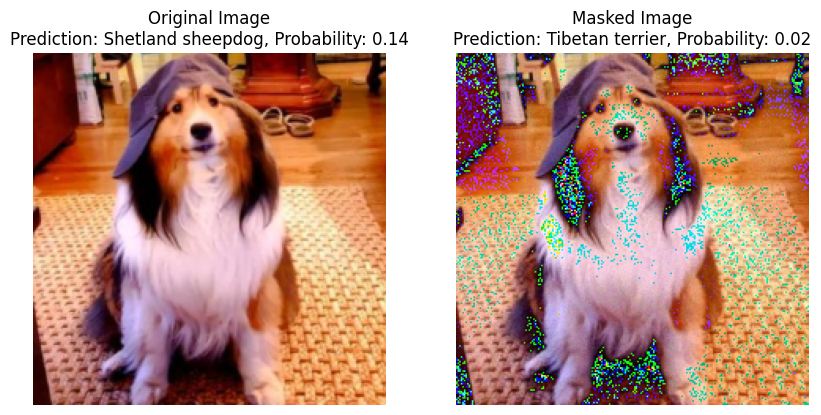

In [ ]:
with torch.no_grad():
    output = model(img_tensor)
    masked = model(img_tensor + current_mask)

    probs = torch.softmax(output, dim=1)[0][output[0].argmax()].item()
    mask_probs = torch.softmax(masked, dim=1)[0][masked[0].argmax()].item()

    prediction = labels[output[0].argmax()]
    mask_prediction = labels[masked[0].argmax()]

    unnormed_img_tensor= unnormalize(img_tensor)
    unnormed_mask_tensor= unnormalize(img_tensor + current_mask)

    img_pil = transforms.functional.to_pil_image(unnormed_img_tensor[0])
    masked_pil = transforms.functional.to_pil_image(unnormed_mask_tensor[0])

plt.figure(figsize=(10, 5))  # Adjust the figsize as needed
plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original Image\nPrediction: {prediction}, Probability: {probs:.2f}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(masked_pil)
plt.title(f"Masked Image\nPrediction: {mask_prediction}, Probability: {mask_probs:.2f}")
plt.axis('off')

plt.show()

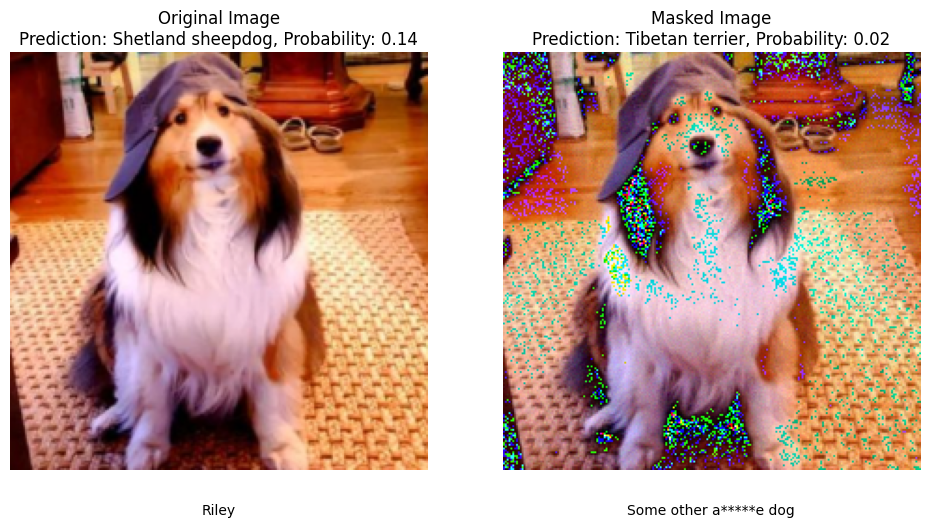

In [ ]:
with torch.no_grad():
    output = model(img_tensor)
    masked = model(img_tensor + current_mask)

    probs = torch.softmax(output, dim=1)[0][output[0].argmax()].item()
    mask_probs = torch.softmax(masked, dim=1)[0][masked[0].argmax()].item()

    prediction = labels[output[0].argmax()]
    mask_prediction = labels[masked[0].argmax()]

    unnormed_img_tensor = unnormalize(img_tensor)
    unnormed_mask_tensor = unnormalize(img_tensor + current_mask)

    img_pil = transforms.functional.to_pil_image(unnormed_img_tensor[0])
    masked_pil = transforms.functional.to_pil_image(unnormed_mask_tensor[0])

plt.figure(figsize=(10, 5))

# ---- Original image ----
ax1 = plt.subplot(1, 2, 1)
ax1.imshow(img_pil)
ax1.set_title(f"Original Image\nPrediction: {prediction}, Probability: {probs:.2f}")
ax1.axis('off')

# Caption BELOW
ax1.text(
    0.5, -0.08,
    "Riley",
    transform=ax1.transAxes,
    ha='center',
    va='top',
    fontsize=10
)

# ---- Masked image ----
ax2 = plt.subplot(1, 2, 2)
ax2.imshow(masked_pil)
ax2.set_title(f"Masked Image\nPrediction: {mask_prediction}, Probability: {mask_probs:.2f}")
ax2.axis('off')

# Caption BELOW
ax2.text(
    0.5, -0.08,
    "Some other a*****e dog",
    transform=ax2.transAxes,
    ha='center',
    va='top',
    fontsize=10
)

plt.tight_layout()
plt.show()

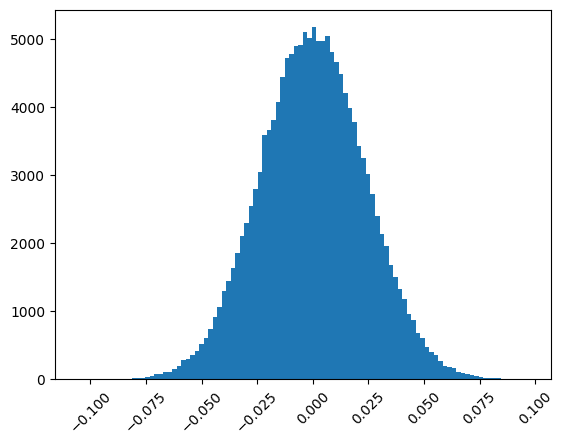

Minimum and maximum difference between the images: -0.10587075352668762 0.09693014621734619


In [ ]:
difference = unnormed_mask_tensor - unnormed_img_tensor
difference_list = difference.view(-1).tolist()

# Plot the histogram
plt.hist(difference_list, bins=100)
plt.xticks(rotation=45)
plt.show()

print("Minimum and maximum difference between the images:", difference.min().item(), difference.max().item())

In [ ]:
# provided code
target_index = torch.tensor(labels.index('robin')).unsqueeze(0).to(device)
print(f"Target index is:\n---------------\n{target_index}\n")

target_class_score = model(img_tensor + current_mask)[0, target_index.item()].item()
print(f"Target class score is:\n---------------\n{target_class_score}\n")

Target index is:
---------------
tensor([15], device='cuda:0')

Target class score is:
---------------
-0.5436604619026184



In [ ]:
img = Image.open("/content/Riley.jpg")
img_tensor = preprocess(img).unsqueeze(0)
img_tensor = img_tensor.to(device)

with torch.no_grad():
    output = model(img_tensor)

print(f"Image tensor on device:\n---------------\n{img_tensor.device}\n")
print(f"Inputs information:\n---------------\nshape:{img_tensor.shape}\nclass: {type(img_tensor)}\n")
print(f"Shape of outputs:\n---------------\n{output.shape}\n")
print(f"Pred Index:\n---------------\n{output[0].argmax()}\n")
print(f"Pred Label:\n---------------\n{labels[output[0].argmax()]}\n")

unnormed_img_tensor= unnormalize(img_tensor)

img_pil = transforms.functional.to_pil_image(unnormed_img_tensor[0])
img_pil.show()

Image tensor on device:
---------------
cuda:0

Inputs information:
---------------
shape:torch.Size([1, 3, 224, 224])
class: <class 'torch.Tensor'>

Shape of outputs:
---------------
torch.Size([1, 1000])

Pred Index:
---------------
230

Pred Label:
---------------
Shetland sheepdog



In [ ]:
n_masks = 1000
eta = 0.005

# Generate a tensor that is a collection of "masks"
# The tensor will have 1000 copies of tensors with the same shape as img_tensor
# The values will have a mean 0 and variance 1 and be scaled down by eta
mask_collection = torch.randn((n_masks, *img_tensor.shape)).to(device) * eta

# initial mask with shape of img_tensor and values of 0
current_mask = torch.zeros_like(img_tensor).to(device)

# compute our starting index
starting_index = model(img_tensor).argmax(1)
print(f"Starting index is:\n---------------\n{starting_index}\n")

starting_class_score = model(img_tensor + current_mask)[0, starting_index.item()].item()
print(f"Starting class score is:\n---------------\n{starting_class_score}\n")

Starting index is:
---------------
tensor([230], device='cuda:0')

Starting class score is:
---------------
5.427470684051514



In [ ]:
# your code here
# Zero our current mask
current_mask = torch.zeros_like(img_tensor).to(device)

# Get our starting label index
starting_label = model(img_tensor).argmax(1).item()
current_label = starting_label

# Target class index
target_index = torch.tensor(labels.index('robin')).unsqueeze(0).to(device)

# Get our starting confidence score
best_score = model(img_tensor + current_mask)[0, target_index.item()].item()

# Run until we reclassify successfully ...
while current_label != target_index:

    # Select a random mask from the collection we created
    mask_candidate_idx = np.random.choice(len(mask_collection))
    mask_candidate = mask_collection[mask_candidate_idx]

    # Don't store gradient information while doing inference
    with torch.no_grad():
        output = model(img_tensor + current_mask + mask_candidate)

    # Based on our mask addition, get our new label and updated score
    current_label = output.argmax(1).item()
    new_score = output[0, target_index.item()].item()

    # If we haven't hit our target yet and also didn't improve the score, just move on
    # NOTE CHANGED TARGET_LABEL TO STARTING_LABEL because our goal is to NOT BE what we are more than be a specific thing
    if new_score < best_score:
        continue

    # Write some monitoring for dopamine
    print(f"Best score is: {best_score:4.6f} -- pred score is: {output[0, current_label].item()} -- prediction is: {current_label}  ", end='\r', flush=True)

    # Update our current score
    best_score = new_score

    # And update our mask
    current_mask += mask_candidate

print(f"\n\nWinner winner: {labels[output[0].argmax()]}")



Winner winner: robin


In [ ]:
# create new img_tensor
img_tensor = preprocess(img).unsqueeze(0).to(device)

# move sample to the right device
img_tensor = img_tensor.to(device)

with torch.no_grad():
    output = model(img_tensor)

y_original = output[0].argmax()

print(f"Pred Index:\n---------------\n{output[0].argmax()}\n")
print(f"Pred Label:\n---------------\n{labels[output[0].argmax().item()]}\n")

Pred Index:
---------------
235

Pred Label:
---------------
German shepherd



In [ ]:
def adversarial_satisfactory(samples, target, clip_min, clip_max):
    samples = torch.clamp(samples, clip_min, clip_max)

    with torch.no_grad():
        preds = model(samples).argmax(dim=1)

    # any other class
    result = preds != target
    return result

In [ ]:
# We're going to routinely clamp the images to this range to make sure that the algorithm doesn't "cheat" by giving us an image that could never be generated from a 24-bit image.
clip_min = -2
clip_max = +2

# randomly seed the generator
generator = torch.Generator().manual_seed(0)

In [ ]:
# now generate a misclassified sample; we'll give ourselves 10 tries
for _ in range(10):
    random_img = torch.FloatTensor(img_tensor.shape).uniform_(clip_min,clip_max, generator=generator).to(device)
    random_class = model(random_img).argmax()

    if adversarial_satisfactory(random_img, y_original, clip_min, clip_max):
        initial_sample = (random_img, y_original)

        print(f"Found misclassified image: {random_class}")
        break

Found misclassified image: 92


In [ ]:
threshold = 0.01 / torch.sqrt(torch.prod(torch.tensor(img_tensor.shape, dtype=torch.float).to(img_tensor.device)))
print(f"Threshold for ending the binary search is: {threshold:.10f}")

Threshold for ending the binary search is: 0.0000257746


In [ ]:
upper_bound, lower_bound = 1,0

while (upper_bound - lower_bound) > threshold:
    midpoint = (upper_bound + lower_bound) / 2.0

    interpolated_sample = (1 - midpoint) * img_tensor + midpoint * random_img

    if adversarial_satisfactory(interpolated_sample, y_original, clip_min, clip_max):
        # the decision boundary lies between midpoint and lower
        upper_bound, lower_bound = midpoint, lower_bound
    else:
        # it's the other way
        upper_bound, lower_bound = upper_bound, midpoint
    print("upper:", upper_bound, "lower:", lower_bound)

boundary_adversarial_example = (1-upper_bound)*img_tensor + upper_bound*random_img

upper: 0.5 lower: 0
upper: 0.25 lower: 0
upper: 0.25 lower: 0.125
upper: 0.25 lower: 0.1875
upper: 0.25 lower: 0.21875
upper: 0.25 lower: 0.234375
upper: 0.25 lower: 0.2421875
upper: 0.24609375 lower: 0.2421875
upper: 0.244140625 lower: 0.2421875
upper: 0.2431640625 lower: 0.2421875
upper: 0.24267578125 lower: 0.2421875
upper: 0.242431640625 lower: 0.2421875
upper: 0.242431640625 lower: 0.2423095703125
upper: 0.24237060546875 lower: 0.2423095703125
upper: 0.242340087890625 lower: 0.2423095703125
upper: 0.2423248291015625 lower: 0.2423095703125


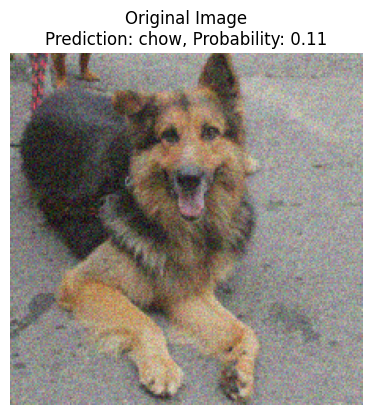

In [ ]:
with torch.no_grad():
    output = model(boundary_adversarial_example)
    probs = torch.softmax(output, dim=1)[0][output[0].argmax()].item()
    prediction = labels[output[0].argmax()]

    unnormed_img_tensor= unnormalize(boundary_adversarial_example)
    img_pil = transforms.functional.to_pil_image(unnormed_img_tensor[0])


plt.figure(figsize=(10, 5))  # Adjust the figsize as needed
plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original Image\nPrediction: {prediction}, Probability: {probs:.2f}")
plt.axis('off')
plt.show()

In [ ]:
gradient_samples = 500
perturbation_scale = 0.1 * (clip_max - clip_min)  # This is going to be different on subsequent steps -- see page 6 of the paper

# Now we sample
perturbation_shape = [gradient_samples] + list(img_tensor.squeeze(0).shape)

# create our new rando tensors
perturbations = torch.randn(*perturbation_shape).to(device)

# to avoid clipping, we're going to take this noise and renormalize it elementwise
perturbations = perturbations / torch.sqrt(torch.sum(
    perturbations**2,                                     # Mean squared error
    axis = tuple(range(len(perturbation_shape)))[1:],     # We want to normalize each sample individually
    keepdims=True,                                        # but don't change the shape of the result
))

# now make the samples we'll be computing the gradients from
eval_samples = torch.clamp(boundary_adversarial_example + perturbation_scale*perturbations, clip_min, clip_max)

# and label them as being satisfactory or not
eval_labels = adversarial_satisfactory(eval_samples, y_original, clip_min, clip_max)

# and convert to +/-1 to mark which side of the decision bounadary they're on
signs = torch.where(eval_labels, 1., -1.)

# and expand to a 4-d tensor bc math
signs = signs.reshape([gradient_samples, 1, 1, 1])

# deal with the edge cases of all samples being of only one class, iykyk
if signs.min()==1.0:  # no -1 means no 'false' satisfactions
    unnormalized_gradient = torch.mean(perturbations, axis = 0)
elif signs.max()==-1.0:
    unnormalized_gradient = -torch.mean(perturbations, axis = 0)
else: #we've got some of each
    mean_signs = torch.mean(signs)
    unnormalized_gradient = torch.mean((signs - mean_signs) * perturbations, axis = 0)

normalized_gradient = unnormalized_gradient / torch.norm(unnormalized_gradient)

In [ ]:
# This is a rough ballpark: just "jump _this_ far to the other side of the boundary"
step_size = torch.norm(boundary_adversarial_example - img_tensor)
print(f"Step size: {step_size}")

Step size: 141.66915893554688


In [ ]:
done=False
while not done:
    new_anchor = boundary_adversarial_example + step_size * normalized_gradient
    if adversarial_satisfactory(new_anchor, y_original, clip_min, clip_max):
        done=True
    step_size/=2.0 # reduce the step size until we succeed in misclassifying

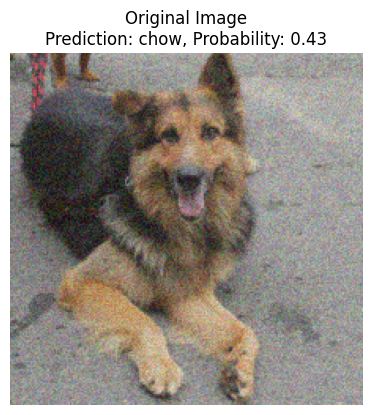

In [ ]:
with torch.no_grad():
    output = model(new_anchor)
    probs = torch.softmax(output, dim=1)[0][output[0].argmax()].item()
    prediction = labels[output[0].argmax()]

    unnormed_adv_tensor= unnormalize(new_anchor)
    img_pil = transforms.functional.to_pil_image(unnormed_img_tensor[0], 'RGB')


plt.figure(figsize=(10, 5))  # Adjust the figsize as needed
plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original Image\nPrediction: {prediction}, Probability: {probs:.2f}")
plt.axis('off')
plt.show()

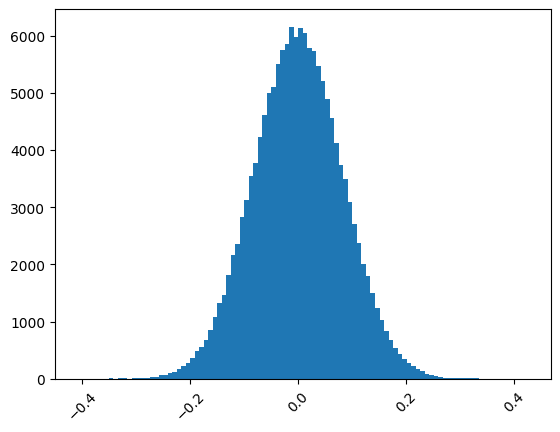

Minimum and maximum difference between the images: -0.4094122648239136 0.42709243297576904


In [ ]:
difference = unnormed_adv_tensor - unnormed_img_tensor
difference_list = difference.view(-1).tolist()

# Plot the histogram
plt.hist(difference_list, bins=100)
plt.xticks(rotation=45)
plt.show()

print("Minimum and maximum difference between the images:", difference.min().item(), difference.max().item())

In [ ]:
import torch

# ---- 1) find any adversarial (init) ----
  x_adv = x.clone()
  for _ in range(2000):
      x_try = torch.clamp(x + 0.2 * torch.randn_like(x, generator=generator), clip_min, clip_max)
      if label(x_try) != y_orig:
        x_adv = x_try
        break

# ---- 2-4) refine with boundary search + gradient-free jumps ----
    for _ in range(iters):

# 2) binary search along line (x -> x_adv) to get "just barely adversarial"
    lo, hi = 0.0, 1.0
      for _ in range(20):
        mid = (lo + hi) / 2.0
          x_mid = (1 - mid) * x + mid * x_adv
          if label(x_mid) != y_orig:
            hi = mid
          else:
            lo = mid
     x_b = (1 - hi) * x + hi * x_adv  # boundary adversarial example

# 3) estimate direction near boundary using label-only probes
    eps = eps_scale * (clip_max - clip_min)
        noise = torch.randn((n_samples,) + tuple(x.shape[1:]), device=x.device, generator=generator)
        noise = noise / (noise.flatten(1).norm(dim=1).view(n_samples, 1, 1, 1) + 1e-12)

        samples = torch.clamp(x_b + eps * noise, clip_min, clip_max)
        with torch.no_grad():
            preds = model(samples).argmax(1)

        signs = torch.where(preds != y_orig, 1.0, -1.0).view(n_samples, 1, 1, 1)
        g = (signs * noise).mean(dim=0)
        g = g / (g.norm() + 1e-12)

# 4) "jump" in estimated direction to get a new adversarial

x_adv = torch.clamp(x_b + step_size * g, clip_min, clip_max)